### Mashiur Rahman

#### Assignment 9: Unsupervised Learning

## 1. Dataset Selection and Preprocessing

### Dataset
The Mall Customer Segmentation dataset was obtained from Kaggle. It contains customer demographic and spending information.

### Objective
The objective is to group customers with similar characteristics using clustering algorithms and visualize the customer groups using dimensionality reduction.

### Dataset Features
- CustomerID: Unique customer identification number
- Gender: Gender of the customer
- Age: Age of the customer
- Annual Income (k$): Customer's annual income
- Spending Score (1-100): Customer spending behaviour score

## Import libraries

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

#### Create the dataset

In [5]:
# Create the complete file path
file_path = Path.home() / "Documents" / "Mall Customer Dataset" / "Mall_Customers.csv"

# Check the file location
print("File path:", file_path)
print("File found:", file_path.exists())

File path: C:\Users\Mashiur\Documents\Mall Customer Dataset\Mall_Customers.csv
File found: True


#### Load the dataset

In [9]:
# Load the dataset using the complete file path
df = pd.read_csv(file_path)

# Display the first five rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Explore the dataset

In [10]:
# Display dataset dimensions
print("Number of rows and columns:", df.shape)

# Display column information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe(include="all"))

Number of rows and columns: (200, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Statistical Summary:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


#### Check data quality

In [11]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Number of duplicate rows: 0


#### Handle missing values and duplicates

In [12]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Fill missing numerical values with the median
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with the mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after processing:")
print(df.isnull().sum())

Missing values after processing:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


#### Prepare and encode the features

In [14]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename Genre to Gender
df = df.rename(columns={"Genre": "Gender"})

# Remove CustomerID because it is only an identifier
X = df.drop(columns=["CustomerID"])

# Convert Gender into a numerical dummy variable
X_encoded = pd.get_dummies(
    X,
    columns=["Gender"],
    drop_first=True,
    dtype=int
)

print("Features after encoding:")
display(X_encoded.head())

Features after encoding:


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


#### Standardize the features

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convert the standardized data into a DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

display(X_scaled_df.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


## 2. Clustering

Two clustering techniques are applied:

1. K-Means Clustering
2. Hierarchical Agglomerative Clustering

The Elbow Method and Silhouette Score are used to determine an appropriate number of clusters.

#### Elbow method for K-Means

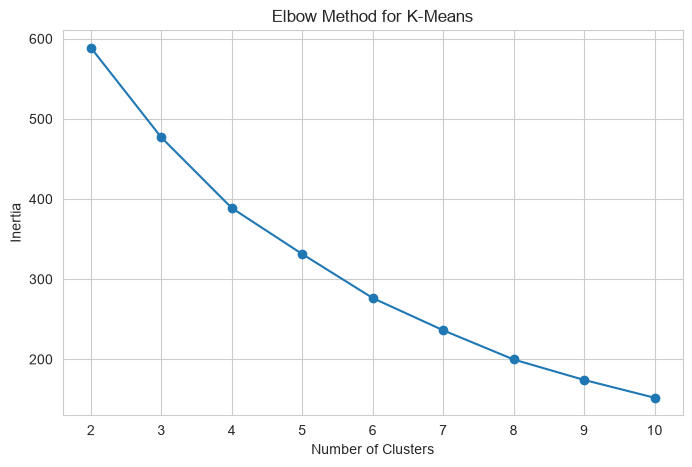

In [17]:
# Calculate inertia for different numbers of clusters
inertia_values = []
cluster_range = range(2, 11)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(cluster_range)
plt.show()

#### K-Means silhouette scores

In [18]:
# Calculate the silhouette score for each number of clusters
kmeans_scores = {}

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    kmeans_scores[k] = score

# Display the scores
kmeans_score_df = pd.DataFrame({
    "Number of Clusters": list(kmeans_scores.keys()),
    "Silhouette Score": list(kmeans_scores.values())
})

display(kmeans_score_df)

,Number of Clusters,Silhouette Score
0,2,0.251815
1,3,0.259513
2,4,0.298397
3,5,0.304060
4,6,0.331074
5,7,0.357377
6,8,0.387993
7,9,0.403092
8,10,0.420764


#### Plot K-Means silhouette scores

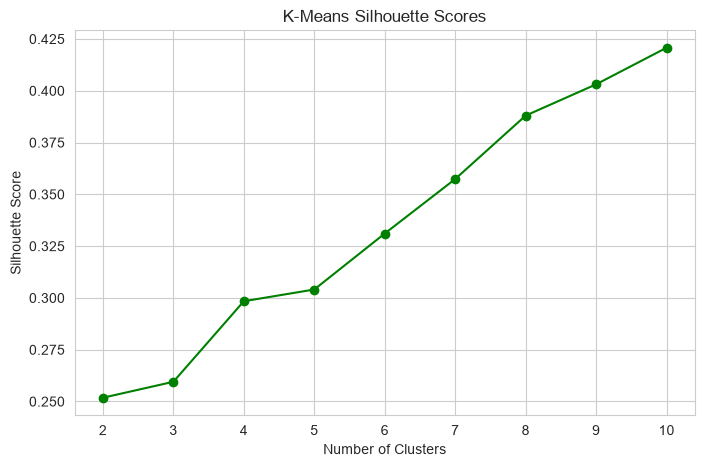

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_score_df["Number of Clusters"],
    kmeans_score_df["Silhouette Score"],
    marker="o",
    color="green"
)

plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.show()

#### Train the best K-Means model

In [20]:
# Select the number of clusters with the highest silhouette score
best_kmeans_k = max(kmeans_scores, key=kmeans_scores.get)

# Train the final K-Means model
kmeans_model = KMeans(
    n_clusters=best_kmeans_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

print("Best number of K-Means clusters:", best_kmeans_k)
print("Best K-Means silhouette score:",
      round(kmeans_scores[best_kmeans_k], 3))

Best number of K-Means clusters: 10
Best K-Means silhouette score: 0.421


#### Hierarchical clustering dendrogram

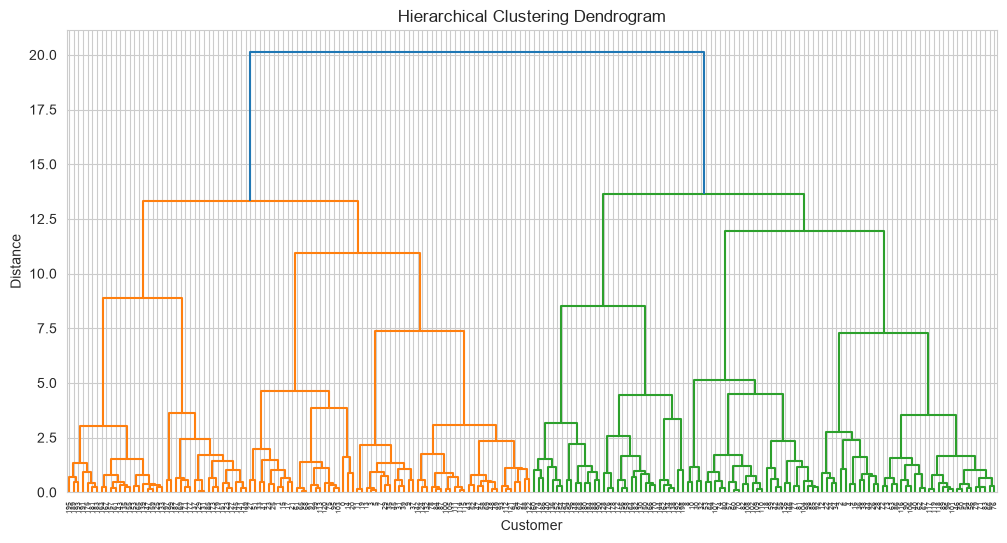

In [21]:
# Create hierarchical linkage
linked_data = linkage(X_scaled, method="ward")

# Display dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked_data)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer")
plt.ylabel("Distance")
plt.show()

#### Hierarchical silhouette scores

In [22]:
# Calculate silhouette scores for hierarchical clustering
hierarchical_scores = {}

for k in cluster_range:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    hierarchical_scores[k] = score

# Create a results table
hierarchical_score_df = pd.DataFrame({
    "Number of Clusters": list(hierarchical_scores.keys()),
    "Silhouette Score": list(hierarchical_scores.values())
})

display(hierarchical_score_df)

,Number of Clusters,Silhouette Score
0,2,0.241780
1,3,0.248345
2,4,0.263226
3,5,0.286994
4,6,0.310245
5,7,0.345558
6,8,0.378880
7,9,0.392258
8,10,0.417625


#### Plot hierarchical silhouette scores

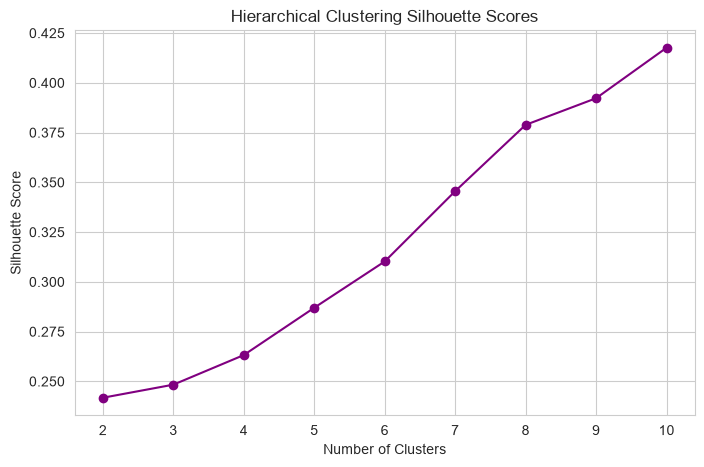

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(
    hierarchical_score_df["Number of Clusters"],
    hierarchical_score_df["Silhouette Score"],
    marker="o",
    color="purple"
)

plt.title("Hierarchical Clustering Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.show()

#### Train the best hierarchical model

In [24]:
# Select the number of clusters with the highest score
best_hierarchical_k = max(
    hierarchical_scores,
    key=hierarchical_scores.get
)

# Train the final hierarchical clustering model
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

print("Best number of hierarchical clusters:",
      best_hierarchical_k)

print("Best hierarchical silhouette score:",
      round(hierarchical_scores[best_hierarchical_k], 3))

Best number of hierarchical clusters: 10
Best hierarchical silhouette score: 0.418


## 3. Dimensionality Reduction

Principal Component Analysis (PCA) is used to reduce the standardized dataset to two dimensions. This makes it possible to visualize the customer clusters on a two-dimensional graph.

#### Apply PCA

In [25]:
# Reduce the data to two principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create a PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)

# Add clustering results
pca_df["K-Means Cluster"] = kmeans_labels
pca_df["Hierarchical Cluster"] = hierarchical_labels

display(pca_df.head())

,Principal Component 1,Principal Component 2,K-Means Cluster,Hierarchical Cluster
0,-0.406383,-0.520714,1,2
1,-1.427673,-0.367310,1,2
2,0.050761,-1.894068,2,9
3,-1.694513,-1.631908,8,8
4,-0.313108,-1.810483,2,9


#### Explained variance

In [26]:
# Display the amount of information retained by PCA
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:",
      round(explained_variance[0] * 100, 2), "%")

print("Variance explained by PC2:",
      round(explained_variance[1] * 100, 2), "%")

print("Total explained variance:",
      round(explained_variance.sum() * 100, 2), "%")

Variance explained by PC1: 33.69 %
Variance explained by PC2: 26.23 %
Total explained variance: 59.92 %


#### Visualize K-Means clusters

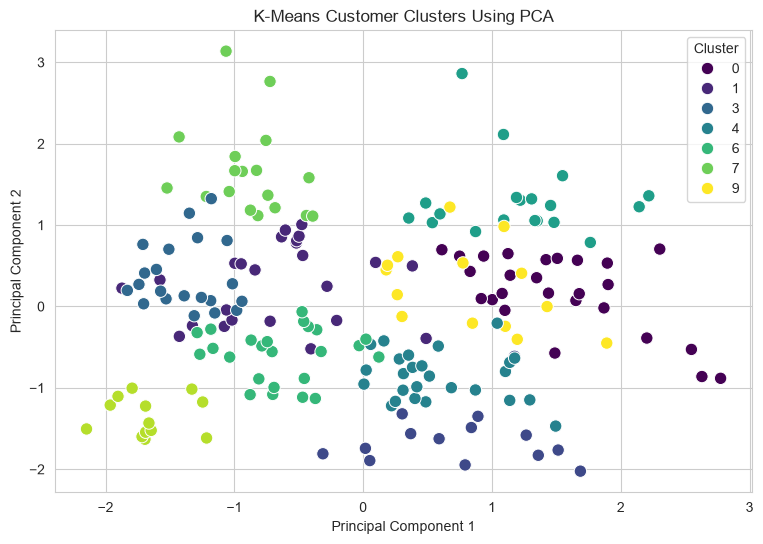

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="K-Means Cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Customer Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

#### Visualize hierarchical clusters

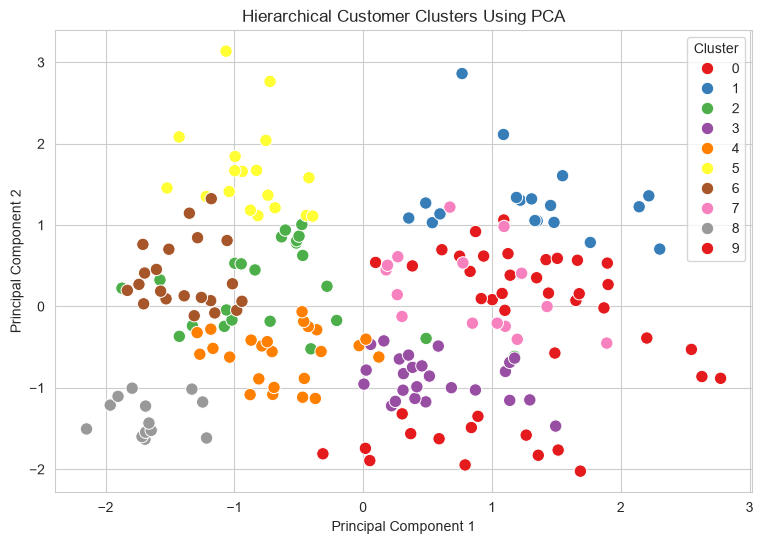

In [28]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Hierarchical Cluster",
    palette="Set1",
    s=80
)

plt.title("Hierarchical Customer Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

## 4. Model Evaluation

In [ ]:
The Silhouette Score is used to evaluate both clustering models. Its value ranges from -1 to 1. A higher score indicates that the clusters are better 
separated and more clearly defined.

#### Compare the models

In [29]:
# Store the best scores
kmeans_final_score = kmeans_scores[best_kmeans_k]
hierarchical_final_score = hierarchical_scores[best_hierarchical_k]

# Create a model comparison table
evaluation_df = pd.DataFrame({
    "Model": [
        "K-Means Clustering",
        "Hierarchical Clustering"
    ],
    "Optimal Clusters": [
        best_kmeans_k,
        best_hierarchical_k
    ],
    "Silhouette Score": [
        kmeans_final_score,
        hierarchical_final_score
    ]
})

evaluation_df["Silhouette Score"] = (
    evaluation_df["Silhouette Score"].round(3)
)

display(evaluation_df)

,Model,Optimal Clusters,Silhouette Score
0,K-Means Clustering,10,0.421
1,Hierarchical Clustering,10,0.418


#### Model comparison graph

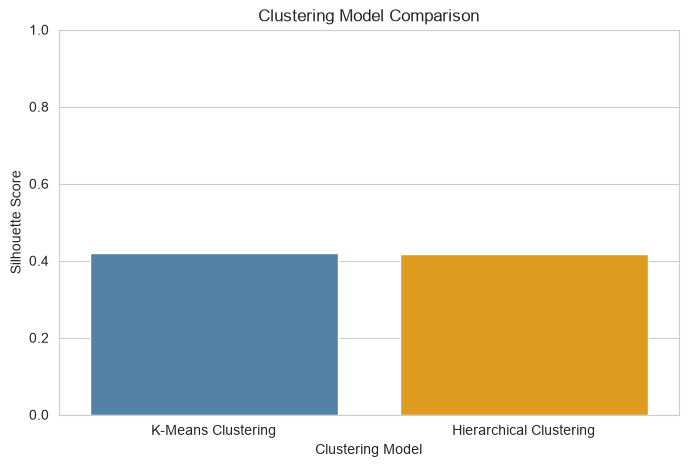

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="Silhouette Score",
    palette=["steelblue", "orange"]
)

plt.title("Clustering Model Comparison")
plt.xlabel("Clustering Model")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)
plt.show()

#### Customer cluster summary

In [32]:
# Select the labels from the best-performing model
if kmeans_final_score > hierarchical_final_score:
    best_model_name = "K-Means Clustering"
    best_model_score = kmeans_final_score
    final_labels = kmeans_labels
else:
    best_model_name = "Hierarchical Clustering"
    best_model_score = hierarchical_final_score
    final_labels = hierarchical_labels

print("Best-performing model:", best_model_name)
print("Silhouette score:", round(best_model_score, 3))

Best-performing model: K-Means Clustering
Silhouette score: 0.421


In [33]:
# Add the best cluster labels to the original dataset
result_df = df.copy()
result_df["Cluster"] = final_labels

# Display the number of customers in each cluster
print("Number of customers in each cluster:")
display(
    result_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Number of Customers")
)

# Display average characteristics of each cluster
cluster_summary = result_df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

print("Average characteristics of each cluster:")
display(cluster_summary)

Number of customers in each cluster:


Cluster
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: Number of Customers, dtype: int64

Average characteristics of each cluster:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,58.85,48.69,39.85
1,25.25,41.25,60.92
2,41.21,26.07,20.14
3,32.19,86.05,81.67
4,54.15,54.23,48.96
5,38.47,85.89,14.21
6,27.96,57.36,47.12
7,33.28,87.11,82.67
8,25.46,25.69,80.54


#### nterpret cluster characteristics

In [34]:
# Automatically describe each cluster
overall_income = result_df["Annual Income (k$)"].mean()
overall_spending = result_df["Spending Score (1-100)"].mean()
overall_age = result_df["Age"].mean()

for cluster, row in cluster_summary.iterrows():
    income_level = (
        "above-average" if row["Annual Income (k$)"] >= overall_income
        else "below-average"
    )
    
    spending_level = (
        "above-average" if row["Spending Score (1-100)"] >= overall_spending
        else "below-average"
    )
    
    age_level = (
        "older" if row["Age"] >= overall_age
        else "younger"
    )
    
    print(
        f"Cluster {cluster}: Customers are generally {age_level}, "
        f"with {income_level} income and {spending_level} spending."
    )

Cluster 0: Customers are generally older, with below-average income and below-average spending.
Cluster 1: Customers are generally younger, with below-average income and above-average spending.
Cluster 2: Customers are generally older, with below-average income and below-average spending.
Cluster 3: Customers are generally younger, with above-average income and above-average spending.
Cluster 4: Customers are generally older, with below-average income and below-average spending.
Cluster 5: Customers are generally younger, with above-average income and below-average spending.
Cluster 6: Customers are generally younger, with below-average income and below-average spending.
Cluster 7: Customers are generally younger, with above-average income and above-average spending.
Cluster 8: Customers are generally younger, with below-average income and above-average spending.
Cluster 9: Customers are generally older, with above-average income and below-average spending.


## 5. Deployment and Monitoring

### Deployment Scenario
The best-performing clustering model could be deployed in a shopping mall's customer relationship management system. When customer information is received, the same preprocessing and scaling steps would be applied before assigning the customer to a segment. The mall could then provide personalized advertisements, loyalty programs, and promotional offers.

### Potential Deployment Challenges
- Latency may occur when processing a large number of customer records.
- Scalability may become a concern as the customer database grows.
- Missing or incorrectly entered customer information could affect cluster assignments.
- Customer purchasing patterns may change over time.
- The meaning and size of the clusters may change when new data becomes available.

### Monitoring and Updating Strategies
- Monitor changes in the distributions of age, income, and spending score.
- Track significant changes in cluster sizes.
- Recalculate the Silhouette Score regularly.
- Review unusual or invalid input values.
- Retrain the model monthly or quarterly using updated customer data.
- Compare the updated model with the existing model before deployment.
- Save the preprocessing scaler and clustering model together to ensure consistent predictions.

#### Save the processed results

In [35]:
# Save customer cluster assignments
result_df.to_csv(
    "mall_customer_cluster_results.csv",
    index=False
)

# Save the model evaluation results
evaluation_df.to_csv(
    "clustering_model_evaluation.csv",
    index=False
)

print("The result files were saved successfully.")

The result files were saved successfully.


## 6. Report Writing

### Introduction
This project analyzed the Mall Customer Segmentation dataset from Kaggle. The purpose was to identify groups of customers with similar demographic and spending characteristics.

### Methodology
The dataset was examined for missing values and duplicate records. CustomerID was removed because it was only an identifier. Gender was converted into numerical form using one-hot encoding. The features were standardized using StandardScaler.

K-Means and Hierarchical Agglomerative Clustering were applied. The Elbow Method, dendrogram, and Silhouette Scores were used to examine the appropriate number of clusters. PCA reduced the data to two dimensions for visualization.

### Results and Interpretation
The models divided customers into groups based on gender, age, annual income, and spending score. The cluster summary displayed the average characteristics of every customer group. These segments could help the mall identify high-income customers, high-spending customers, careful spenders, and other customer types.

### Model Evaluation
The models were evaluated using the Silhouette Score. The model with the higher score was selected as the best-performing model because it produced more clearly separated clusters.

### Deployment and Monitoring
The selected model could be integrated into a customer relationship management system for customer segmentation and targeted marketing. The input data distribution, cluster sizes, and Silhouette Score should be monitored regularly. The model should be retrained as customer behaviour changes and new data becomes available.

### Conclusion
Unsupervised learning successfully identified meaningful customer segments without using a target variable. The analysis demonstrates how clustering and PCA can support customer analysis and marketing decisions.